# Vortex shedding behind a cylinder: the Navier-Stokes equations

We solve the incompressible Navier-Stokes equations

$$u_t + \left(u\cdot\nabla\right) u - \nu\,\Delta u + \nabla p = 0, \qquad \nabla\cdot u = 0,$$

in the channel $(0, 2.2) \times (0, 0.41)$ of `example14` with a cylinder of radius $0.05$ at $(0.2, 0.2)$ removed, with $\nu = 10^{-3}$. The inflow at $x = 0$ is the parabolic profile $u = \left(4 U y (0.41 - y)/0.41^2,\ 0\right)$ with $U = 1.5$, the walls and the cylinder are no slip, and the outflow at $x = 2.2$ is free. The mean inflow velocity is $\bar U = 1$ and the Reynolds number $Re = \bar U D/\nu = 100$ (DFG benchmark 2D-2 of Schäfer and Turek, 1996). At this Reynolds number the flow does not settle to a steady state. Vortices leave the cylinder alternately from the top and the bottom, the von Kármán vortex street.

The notebook is kept to the essentials: mesh, spaces, time stepping, a plot of the solution at the final time and a movie of the speed. The forces on the cylinder are computed in `example14` for the steady flow.

In [1]:
import time
import matplotlib.pyplot as plt
import femd as fd
from femd import dot, grad, div, inner, dx

**Mesh and spaces.** Taylor-Hood elements, $P_2$ for the velocity with the inflow profile and no slip built into the space, and $P_1$ for the pressure. The sides of the channel are numbered 1 (bottom), 2 (outflow), 3 (top), 4 (inflow), and the cylinder, given by 64 points, is 5. With `max_edge=0.02` the mesh has about 11 000 triangles and 51 000 unknowns.

In [2]:
H = 0.41
m = fd.triangulate([(0, 0), (2.2, 0), (2.2, H), (0, H)], holes=[fd.circle(0.2, 0.2, 0.05, 64)],
                   edge_markers=[1, 2, 3, 4], max_edge=0.035, min_angle=28, smooth=20)

x, y = fd.x, fd.y
inflow = (4 * 1.5 * y * (H - y) / H**2, 0.0)
V = fd.VectorFunctionSpace(m, 2, dirichlet={4: inflow, 1: (0, 0), 3: (0, 0), 5: (0, 0)})
Q = fd.LagrangeSpace(m, 1)
W = fd.ProductSpace(V, Q)
print(m.ntriangles, "triangles,", W.dim, "unknowns")

3978 triangles, 17546 unknowns


**Time stepping.** With $w = (u, p)$ the weak form is $M w' = f(w)$ with

$$\left(M w', (v, q)\right) = (u_t, v), \qquad \left(f(w), (v, q)\right) = -\nu\,(\nabla u, \nabla v) - \left(\left(u\cdot\nabla\right) u, v\right) + (p, \nabla\cdot v) + (q, \nabla\cdot u),$$

a differential-algebraic system, since the pressure has no time derivative. We solve it with the two-stage Radau IIA method, `fd.IRK(M, f, dt, "radau", 2)`, which is made for such systems. The initial state must satisfy the constraint $\nabla\cdot u = 0$ and the boundary conditions, so we start from the Stokes flow, the solution without $u_t$ and without the convection term.

Each step solves the nonlinear stage equations by a simplified Newton method with the Jacobian of $f$ computed from the form symbolically. Its sparse factorization is the largest sequential cost of a step, so `newton="frozen"` keeps it from step to step and renews it only when Newton needs more than `irk.refresh` (6) iterations.

In [3]:
nu, dt = 0.001, 0.02
(u, p), (v, q) = fd.TrialFunctions(W), fd.TestFunctions(W)

w = fd.Function(W.unconstrained)                       # (u, p), with the inflow data
stokes = (nu * inner(grad(u), grad(v)) - p * div(v) - q * div(u)) * dx
w.vector[:] = fd.solve(stokes, dot(fd.as_vector([0.0, 0.0]), v) * dx).vector

uw, pw = w
M = fd.form(dot(u, v) * dx)
f = fd.form((-nu * inner(grad(uw), grad(v)) - dot(dot(grad(uw), uw), v) + pw * div(v) + q * div(uw)) * dx)
irk = fd.IRK(M, f, dt, "radau", 2, tol=1e-10, newton="frozen")

**The time loop**, up to $t = 4$, by which time the vortices leave the cylinder alternately from the top and the bottom. We time it, count the factorizations out of the 200 steps, and keep the solution every other step for the movie below.

In [4]:
T = 4.0
frames = {}                                            # t -> coefficients, for the movie
t0 = time.perf_counter()
for n in range(1, round(T / dt) + 1):
    irk.step(w)
    if n % 2 == 0:
        frames[n * dt] = w.vector.copy()
print(f"{time.perf_counter() - t0:.0f} s, {irk.factorizations} factorizations in {round(T / dt)} steps")

44 s, 179 factorizations in 200 steps


**The solution at $t = 4$.** The speed $|u|$ and the pressure $p$. The velocity is $P_2$, so it is drawn on a sub-triangulation of each element (`refine=4`).

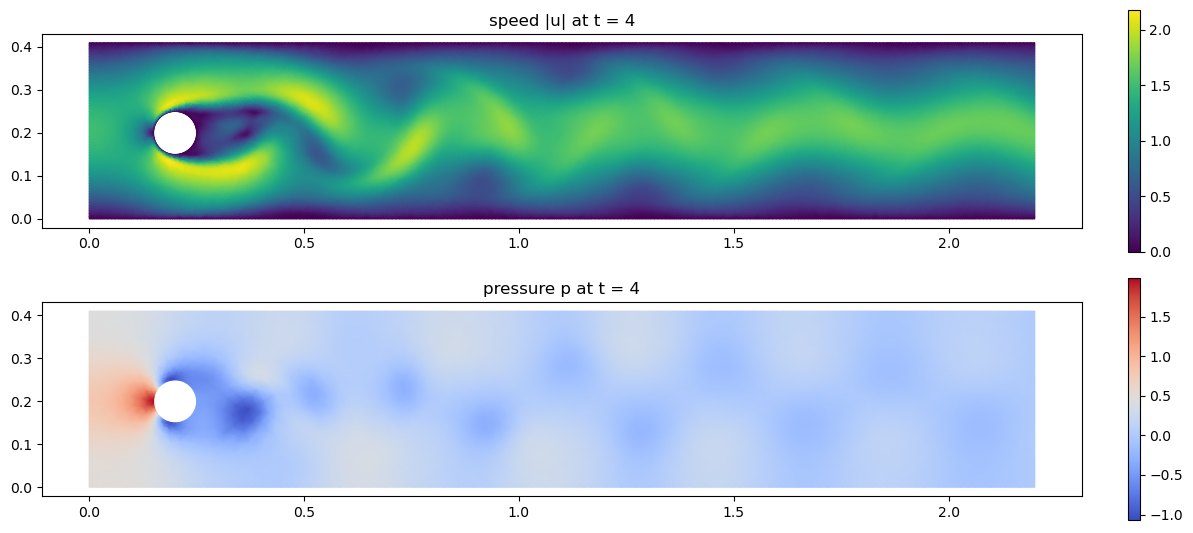

In [5]:
uh, ph = w.split()
fig, axs = plt.subplots(2, 1, figsize=(12, 5.5))
uh.plot(axs[0], quiver=False, refine=4, cmap="viridis")
axs[0].set_title(f"speed |u| at t = {T:g}")
ph.plot(axs[1], cmap="coolwarm")
axs[1].set_title(f"pressure p at t = {T:g}")
for ax in axs:
    ax.set_aspect("equal")
plt.tight_layout()
plt.show()

**A movie of the speed.** Each kept solution is drawn as one frame with a fixed color scale, and the frames are written to `output/example15.mp4` with ffmpeg, or to an animated GIF when ffmpeg is not installed (`brew install ffmpeg` on macOS). The sub-triangulation is coarser here (`refine=2`) to keep the drawing quick.

written output/example15.gif


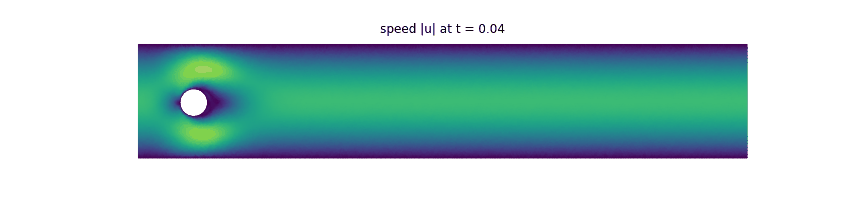

In [6]:
import os
import matplotlib.animation as animation
from IPython.display import Video, Image

os.makedirs("output", exist_ok=True)
ws = fd.Function(W.unconstrained)
fig, ax = plt.subplots(figsize=(12, 2.8))

def draw(t):
    ax.clear()
    ws.vector[:] = frames[t]
    ws.split()[0].plot(ax, quiver=False, refine=2, colorbar=False, cmap="viridis", vmin=0, vmax=2.2)
    ax.set_title(f"speed |u| at t = {t:.2f}")
    ax.set_axis_off()

anim = animation.FuncAnimation(fig, draw, frames=sorted(frames), interval=100)
if animation.writers.is_available("ffmpeg"):
    name = "output/example15.mp4"
    anim.save(name, writer=animation.FFMpegWriter(fps=10, bitrate=2000), dpi=100)
else:
    name = "output/example15.gif"
    anim.save(name, writer=animation.PillowWriter(fps=10), dpi=72)
plt.close(fig)
print("written", name)
Video(name, embed=True) if name.endswith(".mp4") else Image(name)